**Import packages and dependecies**

In [ ]:
%pip install -q -e ..

In [5]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from fda.basis import BSplineBasis
from fda.registration import (
    powerWarp,
    mobiusWarp,
    ramsayWarp,
    curveRegistration
)

warnings.filterwarnings("ignore")

### I. Comparing Different Warping Methods h(t)

**Example 1: Power Warping Method**

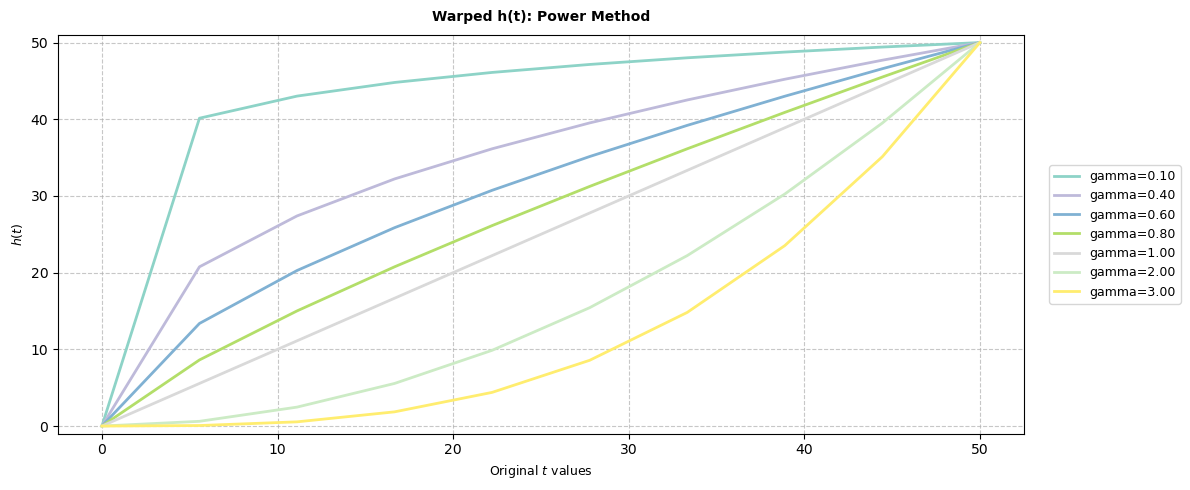

In [6]:
# Set up parameters
domain = (0, 50)
t_grid = np.linspace(domain[0], domain[1], 10)

# Initialize warper function (i.e. h(t))
warper = powerWarp(t_grid)

# Define list of different possible gamma values to apply to powerWarp 
gamma_list = [0.1, 0.4, 0.6, 0.8, 1.0, 2.0, 3.0]

# Create plot showing how different gamma values affect the way t gets warped
fig, ax = plt.subplots(figsize=(12,5))
for ind, gamma in enumerate(gamma_list):

    # Plot warped t values
    warped_t = warper.warp(gamma=gamma)

    ax.plot(
        t_grid,
        warped_t,
        linewidth=2,
        label=f"gamma={gamma:.2f}",
        color=plt.cm.get_cmap("Set3", len(gamma_list))(ind)
    )

    # Apply formatting
    ax.set_title(
        f"Warped h(t): Power Method", 
        fontsize=10, 
        fontweight="bold", 
        pad=10
    )
    ax.set_xlabel("Original $t$ values", fontsize=9)
    ax.set_ylabel(r"$h(t)$", fontsize=9)
    ax.set_ylim(domain[0]-1, domain[1]+1)
    ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(True, linestyle='--', alpha=0.7)
    
# Display the plot
plt.tight_layout()
plt.show()

**Example 2: Moebius Warping Method**

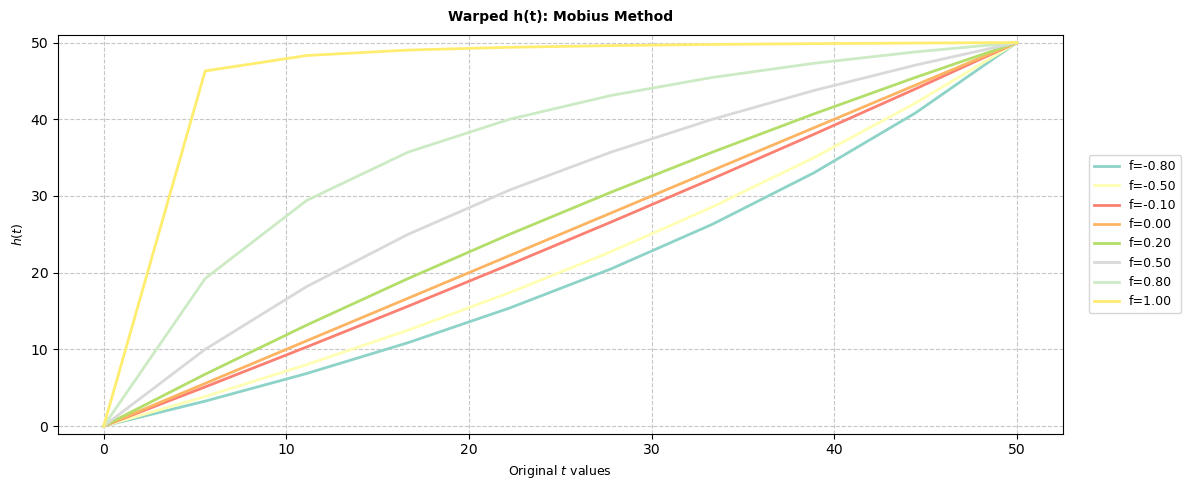

In [7]:
# Set up parameters
domain = (0, 50)
t_grid = np.linspace(domain[0], domain[1], 10)

# Initialize warper function (i.e. h(t))
warper = mobiusWarp(t_grid)

# Define list of different possible f values to apply to mobiusWarp 
f_list = [-0.8, -0.5, -0.1, 0.0, 0.2, 0.5, 0.8, 1.0]

# Create plot showing how different f values affect the way t gets warped
fig, ax = plt.subplots(figsize=(12,5))
for ind, f in enumerate(f_list):

    # Plot warped t values
    warped_t = warper.warp(f=f)

    ax.plot(
        t_grid,
        warped_t,
        linewidth=2,
        label=f"f={f:.2f}",
        color=plt.cm.get_cmap("Set3", len(f_list))(ind)
    )

    # Apply formatting
    ax.set_title(
        f"Warped h(t): Mobius Method", 
        fontsize=10, 
        fontweight="bold", 
        pad=10
    )
    ax.set_xlabel("Original $t$ values", fontsize=9)
    ax.set_ylabel(r"$h(t)$", fontsize=9)
    ax.set_ylim(domain[0]-1, domain[1]+1)
    ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(True, linestyle='--', alpha=0.7)
    
# Display the plot
plt.tight_layout()
plt.show()

**Example 3: Ramsay Warping Method**

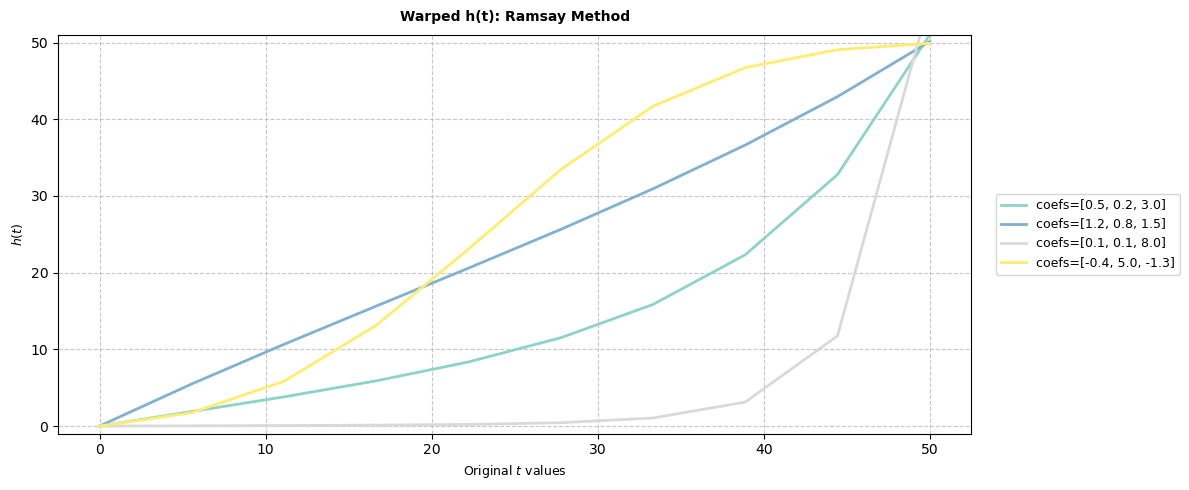

In [8]:
# Set up parameters
domain = (0, 50)
t_grid = np.linspace(domain[0], domain[1], 10)
basis_object = BSplineBasis(
    domain_range=domain,
    n_basis=3,
    degree=2
)

# Initialize warper function (i.e. h(t))
warper = ramsayWarp(t_grid, basis_object)

# Define list of different possible coefficient values to apply to ramsayWarp 
# The number of coefficients need to match the number of basis (n_basis)
coefficients_list = [
    [0.5, 0.2, 3.0],
    [1.2, 0.8, 1.5],
    [0.1, 0.1, 8.0],
    [-0.4, 5.0, -1.3]
]


# Create plot showing how different f values affect the way t gets warped
fig, ax = plt.subplots(figsize=(12,5))
for ind, coefficents in enumerate(coefficients_list):

    # Plot warped t values
    warped_t = warper.warp(coefficients=coefficents)

    ax.plot(
        t_grid,
        warped_t,
        linewidth=2,
        label=f"coefs={coefficents}",
        color=plt.cm.get_cmap("Set3", len(coefficients_list))(ind)
    )

    # Apply formatting
    ax.set_title(
        f"Warped h(t): Ramsay Method", 
        fontsize=10, 
        fontweight="bold", 
        pad=10
    )
    ax.set_xlabel("Original $t$ values", fontsize=9)
    ax.set_ylabel(r"$h(t)$", fontsize=9)
    ax.set_ylim(domain[0]-1, domain[1]+1)
    ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
    ax.grid(True, linestyle='--', alpha=0.7)
    
# Display the plot
plt.tight_layout()
plt.show()

### II. Optimizing Curve Registration or Alignment

**Comparing Optimized REGSSE Performance Under Different Warping Methods:**

In [9]:
# Set up parameters
domain = (0, 100)
t_grid = np.linspace(domain[0], domain[1], 150)

# Define x(t)
x_basis = BSplineBasis(
    domain_range=domain,
    n_basis=6,
    degree=3
)
x_signal = np.exp(-0.5 * ((t_grid - 30) / 10) ** 2)
x_coefs = np.linalg.lstsq(x_basis.evaluate(t_grid), x_signal, rcond=None)[0]

# Basis object if using Ramsay method for setting h(t)
ramsay_basis = BSplineBasis(
    domain_range=domain,
    n_basis=4,
    degree=3
)

# Target curve that we want to align x(t) towards
target_basis = BSplineBasis(
    domain_range=domain,
    n_basis=6,
    degree=3
)
target_signal = np.exp(-0.5 * ((t_grid - 70) / 10) ** 2)
target_coefs = np.linalg.lstsq(target_basis.evaluate(t_grid), target_signal, rcond=None)[0]

# Initialize curve registration
curve_registration_power = curveRegistration(
    t_grid=t_grid,
    x_basis=x_basis,
    x_coefs=x_coefs,
    target_basis=target_basis,
    target_coefs=target_coefs,
    warping_method="power",
    ramsay_basis=ramsay_basis
)

curve_registration_mobius = curveRegistration(
    t_grid=t_grid,
    x_basis=x_basis,
    x_coefs=x_coefs,
    target_basis=target_basis,
    target_coefs=target_coefs,
    warping_method="mobius",
    ramsay_basis=ramsay_basis
)

curve_registration_ramsay = curveRegistration(
    t_grid=t_grid,
    x_basis=x_basis,
    x_coefs=x_coefs,
    target_basis=target_basis,
    target_coefs=target_coefs,
    warping_method="ramsay",
    ramsay_basis=ramsay_basis
)


# Retrieve the REGSSE after optimization
optimization_results_power = curve_registration_power.optimize(initial_guess=None, optimization_method="L-BFGS-B")
optimization_results_mobius = curve_registration_mobius.optimize(initial_guess=None, optimization_method="L-BFGS-B")
optimization_results_ramsay = curve_registration_ramsay.optimize(initial_guess=None, optimization_method="L-BFGS-B")

all_optimization_results = {
    "power": optimization_results_power,
    "mobius": optimization_results_mobius,
    "ramsay": optimization_results_ramsay
}

for warping_method, optimization_results in all_optimization_results.items():
    succeeded = optimization_results.success
    best_params = optimization_results.x
    regsse = optimization_results.fun

    print(f"\nWarping Method: {warping_method.upper()}")
    print("-"*100)
    print(f"Optimization Succeeded: {succeeded}")
    print(f"Optimized Parameters:   {np.round(best_params, 4)}")
    print(f"Minimized REGSSE:       {regsse:.6f}")


Warping Method: POWER
----------------------------------------------------------------------------------------------------
Optimization Succeeded: True
Optimized Parameters:   [3.5017]
Minimized REGSSE:       2.625146

Warping Method: MOBIUS
----------------------------------------------------------------------------------------------------
Optimization Succeeded: True
Optimized Parameters:   [-0.95]
Minimized REGSSE:       23.624519

Warping Method: RAMSAY
----------------------------------------------------------------------------------------------------
Optimization Succeeded: True
Optimized Parameters:   [-20.0527  18.124   -4.0016   5.93  ]
Minimized REGSSE:       0.860569


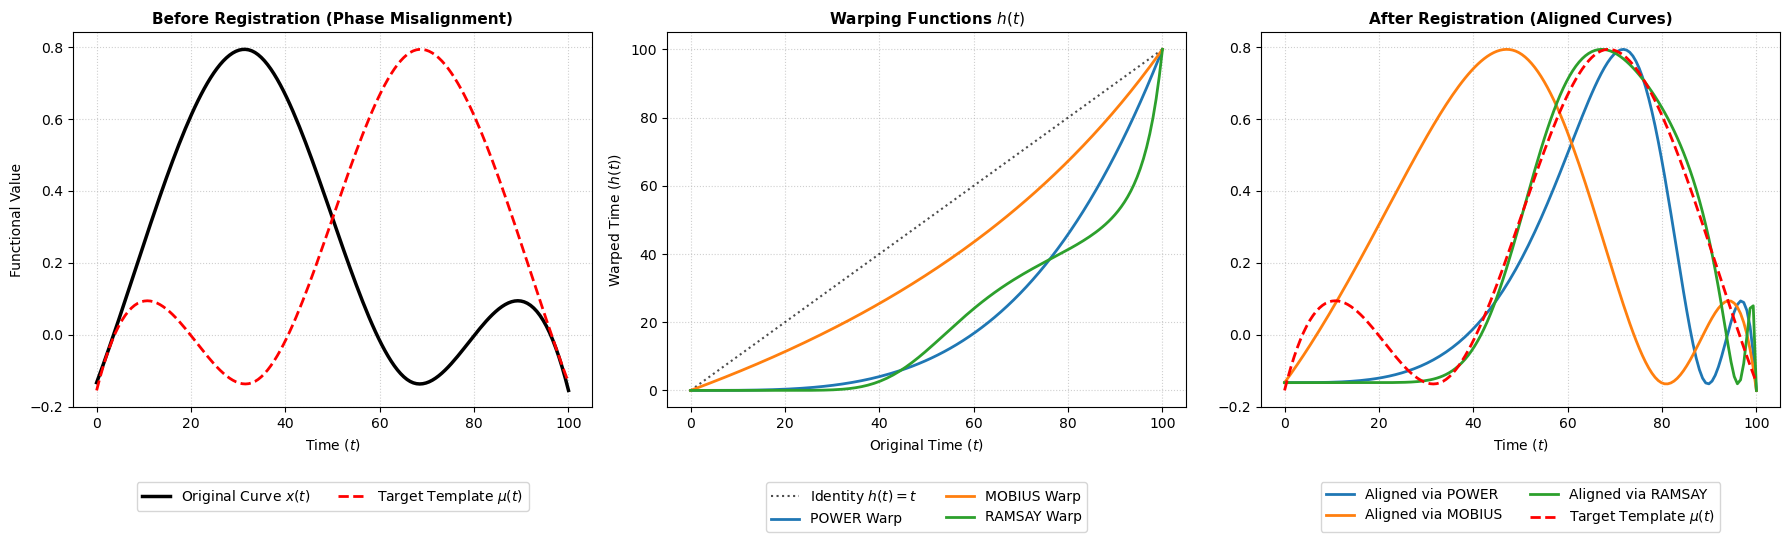

In [ ]:
# 1. Setup the figure layout (3 columns: Original vs Target, Warping Functions, Registered Curves)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=False)
colors = {"power": "#1f77b4", "mobius": "#ff7f0e", "ramsay": "#2ca02c"}

# Evaluate the unwarped reference profiles
# h(t) = t baseline (Initial identity line)
t_baseline = t_grid 
x_original = curve_registration_power.x_basis.evaluate(t_baseline) @ curve_registration_power.x_coefs
mu_target = curve_registration_power.target_basis.evaluate(t_baseline) @ curve_registration_power.target_coefs

# -------------------------------------------------------------
# PANEL 1: Unaligned Baseline
# -------------------------------------------------------------
axes[0].plot(t_grid, x_original, label="Original Curve $x(t)$", color="black", linewidth=2.5)
axes[0].plot(t_grid, mu_target, label="Target Template $\mu(t)$", color="red", linestyle="--", linewidth=2)
axes[0].set_title("Before Registration (Phase Misalignment)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Time ($t$)")
axes[0].set_ylabel("Functional Value")
axes[0].grid(True, linestyle=":", alpha=0.6)

# Place Legend 1 below the subplot
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# -------------------------------------------------------------
# PANELS 2 & 3: Loop Through Each Warping Framework to Compare
# -------------------------------------------------------------
# Plot the identity line h(t) = t on the warping panel as a baseline reference
axes[1].plot(t_grid, t_grid, color="black", linestyle=":", alpha=0.7, label="Identity $h(t)=t$")

# Mapping our registration objects and their corresponding optimizer results
registration_models = {
    "power": (curve_registration_power, optimization_results_power),
    "mobius": (curve_registration_mobius, optimization_results_mobius),
    "ramsay": (curve_registration_ramsay, optimization_results_ramsay),
}

for method, (model, result) in registration_models.items():
    if result.success:
        # Extract the optimized parameters
        best_params = result.x
        
        # Track and build the warped timeline h(t) using the internal method mapping
        h_t_optimized = model._warping_function(best_params)
        h_t_optimized = np.clip(h_t_optimized, model.t_min, model.t_max)
        
        # Evaluate the registered curve: x_registered(t) = x(h(t))
        x_registered = model.x_basis.evaluate(h_t_optimized) @ model.x_coefs
        
        # Plot the warping function h(t) vs t
        axes[1].plot(t_grid, h_t_optimized, label=f"{method.upper()} Warp", color=colors[method], linewidth=2)
        
        # Plot the newly aligned functional curve profile
        axes[2].plot(t_grid, x_registered, label=f"Aligned via {method.upper()}", color=colors[method], linewidth=2)

# Format Warping Function Panel
axes[1].set_title("Warping Functions $h(t)$", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Original Time ($t$)")
axes[1].set_ylabel("Warped Time ($h(t)$)")
axes[1].grid(True, linestyle=":", alpha=0.6)

# Place Legend 2 below the subplot
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# Format Registered Curve Panel
axes[2].plot(t_grid, mu_target, color="red", linestyle="--", linewidth=2, label="Target Template $\mu(t)$")
axes[2].set_title("After Registration (Aligned Curves)", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Time ($t$)")
axes[2].grid(True, linestyle=":", alpha=0.6)

# Place Legend 3 below the subplot
axes[2].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

# Adjust layout bounding box to accommodate the bottom legends gracefully
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()